Loading the model...

Testing prediction on a single image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: Pneumonia with probability 71.79%


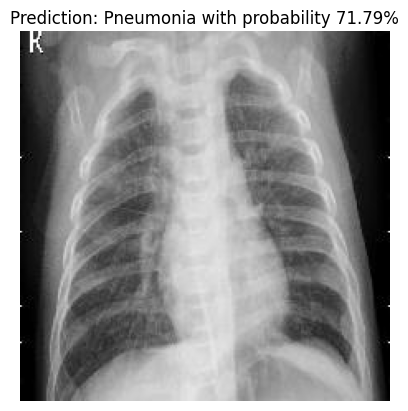

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

def load_model(model_path):
    """Load the trained model."""
    return tf.keras.models.load_model(model_path)

def preprocess_image(image_path, target_size=(224, 224)):
    """Preprocess a single image."""
    from tensorflow.keras.utils import load_img, img_to_array

    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img, img_array

def evaluate_model(model, test_dir, target_size=(224, 224), batch_size=32):
    """Evaluate the model on a batch of test data."""
    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)
    test_dataset = test_datagen.flow_from_directory(
        test_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode="categorical"
    )

    loss, accuracy = model.evaluate(test_dataset)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

def predict_single_image(model, image_path, class_names):
    """Predict the class of a single image."""
    img_original, img_array = preprocess_image(image_path)

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)
    confidence = predictions[0][predicted_class] * 100

    result_text = f"Prediction: {class_names[predicted_class]} with probability {confidence:.2f}%"
    print(result_text)

    # Display the image with prediction
    plt.imshow(img_original)
    plt.title(result_text)
    plt.axis("off")
    plt.show()

def main():
    model_path = r"C:\Users\Legion\Desktop\react\pneumo\resnet50\model\ResNet50_Pneumo.keras"
    test_dir = r"C:\Users\Legion\Desktop\react\pneumo\data\balanced\test"  # Update with your test dataset path
    single_image_path = r"C:\Users\Legion\Desktop\react\pneumo\data\processed\train\PNEUMONIA\person1318_virus_2274.jpeg"  # Update with a test image path
    class_names = ["Normal", "Pneumonia"]

    # Load the model
    print("Loading the model...")
    model = load_model(model_path)

    # Evaluate the model
    """print("\nEvaluating the model on the test dataset...")
    evaluate_model(model, test_dir)"""

    # Predict on a single image
    print("\nTesting prediction on a single image...")
    predict_single_image(model, single_image_path, class_names)

if __name__ == "__main__":
    main()
